# Clustering Exploration

This notebook explores whether slab properties, weak-layer properties, and Extended Column Test (ECT) results form useful clusters in the SnowPylot dataset. The workflow is intentionally linear: load CAAML pits, build slabs from the layer of concern, derive slab/weak-layer/ECT features, then run a fixed two-cluster PCA/K-means workflow across multiple feature sets.

The cluster labels are exploratory. The `near_avalanche` marker is held out as a contextual verification label, not as an input feature. Terrain, season, location, operation, elevation, slope, and aspect are intentionally excluded from PCA and clustering inputs.

## Setup

All imports, paths, model settings, feature-set definitions, and display labels live here so the rest of the notebook reads like an analysis narrative. D11 and ECT feature sets are treated as sensitivity analyses because they answer narrower questions and can have substantially different data coverage.

In [1]:
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
    NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SNOWPYT_MECHPARAMS_SRC = PROJECT_ROOT.parent / "SnowPyt-MechParams" / "src"
for import_path in [NOTEBOOK_DIR, SNOWPYT_MECHPARAMS_SRC]:
    import_path_text = str(import_path)
    if import_path.exists() and import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from caaml_utils import parse_caaml_directory
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.models import Pit

try:
    from tqdm.auto import tqdm
except ImportError:

    def tqdm(items, **_kwargs):
        return items

warnings.filterwarnings(
    "ignore",
    message="Using UFloat objects with std_dev==0 may give unexpected results.",
)

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = PROJECT_ROOT / "snowpits" / "2015_2025"
RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 2
ECT_MAX_TAPS = 31.0
CLUSTER_ORDER_COLUMN = "slab_weight_N_m2"

ANALYSIS_METADATA_COLUMNS = [
    "pit_id",
    "slab_id",
    "near_avalanche",
    "near_avalanche_raw",
]

FEATURE_SET_DEFINITIONS = {
    "slab_load": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
    ],
    "slab_load_structure": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
    ],
    "weak_layer_core": [
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "slab_plus_weak_layer": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "ect_response_sensitivity": [
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_mean_propagating_taps",
        "ect_instability_index",
    ],
    "slab_weak_layer_plus_ect": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_mean_propagating_taps",
        "ect_instability_index",
    ],
    "d11_sensitivity": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "bending_stiffness_D11_N_mm",
    ],
    "slab_weak_layer_d11_sensitivity": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "bending_stiffness_D11_N_mm",
    ],
    "log_transform_sensitivity": [
        "log1p_slab_thickness_cm",
        "log1p_slab_weight_N_m2",
        "n_layers",
        "log1p_cumulative_hhi_cm",
        "log1p_slab_mean_hhi",
        "log1p_weak_layer_depth_top_cm",
        "log1p_weak_layer_thickness_cm",
        "log1p_weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
}

FORBIDDEN_PCA_FEATURE_COLUMNS = set(ANALYSIS_METADATA_COLUMNS) | {
    "near_avalanche_label",
    "pit_date",
    "season",
    "month",
    "operation_name",
    "country",
    "region",
    "elevation",
    "slope_angle",
    "aspect",
}
LOG_TRANSFORM_SOURCE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "weak_layer_depth_top_cm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
]

COVERAGE_FEATURE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "n_layers",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "weak_layer_depth_top_cm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
    "weak_layer_persistent_grain",
    "bending_stiffness_D11_N_mm",
    "ect_propagation_rate",
    "ect_mean_taps",
    "ect_mean_propagating_taps",
    "ect_instability_index",
    "ect_count",
    "ect_parsed_count",
]
FEATURE_DISPLAY_NAMES = {
    "slab_thickness_cm": "Slab thickness (cm)",
    "slab_weight_N_m2": "Slab weight (N/m2)",
    "n_layers": "Slab layer count",
    "cumulative_hhi_cm": "Cumulative HHI (cm)",
    "slab_mean_hhi": "Thickness-weighted mean slab HHI",
    "weak_layer_depth_top_cm": "Weak-layer top depth (cm)",
    "weak_layer_thickness_cm": "Weak-layer thickness (cm)",
    "weak_layer_hhi": "Weak-layer HHI",
    "weak_layer_persistent_grain": "Weak-layer persistent grain flag",
    "bending_stiffness_D11_N_mm": "Bending stiffness D11 (N mm)",
    "ect_propagation_rate": "ECT propagation rate",
    "ect_mean_taps": "ECT mean taps",
    "ect_mean_propagating_taps": "ECT mean propagating taps",
    "ect_instability_index": "ECT instability index",
    "ect_count": "ECT count",
    "ect_parsed_count": "Parsed ECT count",
}
for source_column in LOG_TRANSFORM_SOURCE_COLUMNS:
    FEATURE_DISPLAY_NAMES[f"log1p_{source_column}"] = (
        f"log1p {FEATURE_DISPLAY_NAMES[source_column]}"
    )

WEIGHT_METHODS = {
    "density": "kim_jamieson_table2",
    "slab_weight": "sum_layer_weight",
}
D11_METHODS = {
    "density": "kim_jamieson_table2",
    "elastic_modulus": "schottner",
    "poissons_ratio": "kochle",
    "D11": "weissgraeber_rosendahl",
}

pd.options.display.float_format = "{:,.3f}".format

## Helper Functions

These helpers keep the analysis cells short. They handle uncertain values, missing values, slab-level hand-hardness summaries, and ECT score parsing.


In [2]:
def nominal_value(value):
    """Return a finite float from a scalar, unit tuple/list, or uncertainties value."""
    if value is None:
        return np.nan
    if isinstance(value, (list, tuple)):
        if not value:
            return np.nan
        value = value[0]
    value = getattr(value, "nominal_value", value)
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def cumulative_hhi_cm(slab):
    """Sum layer hand hardness index multiplied by layer thickness in cm."""
    total = 0.0
    for layer in slab.layers:
        hhi = nominal_value(layer.hand_hardness_index)
        thickness = nominal_value(layer.thickness)
        if np.isnan(hhi) or np.isnan(thickness):
            return np.nan
        total += hhi * thickness
    return total


def slab_mean_hhi(slab):
    """Return thickness-weighted mean slab hand hardness index."""
    cumulative_hhi = cumulative_hhi_cm(slab)
    slab_thickness = nominal_value(slab.total_thickness)
    if np.isnan(cumulative_hhi) or np.isnan(slab_thickness) or slab_thickness <= 0:
        return np.nan
    return cumulative_hhi / slab_thickness


def weak_layer_persistent_grain_flag(weak_layer):
    """Flag depth hoar, facets, or surface hoar weak layers."""
    if weak_layer is None:
        return np.nan
    grain_form = getattr(weak_layer, "main_grain_form", None)
    if grain_form is None:
        raw_grain_form = getattr(weak_layer, "grain_form", None)
        grain_form = str(raw_grain_form)[:2] if raw_grain_form is not None else None
    if grain_form is None:
        return np.nan
    return float(str(grain_form).upper() in {"DH", "FC", "SH"})


def log1p_positive(series):
    """Return log1p for non-negative finite values and NaN otherwise."""
    numeric_series = pd.to_numeric(series, errors="coerce")
    return np.where(numeric_series >= 0, np.log1p(numeric_series), np.nan)


def mean_or_nan(values):
    """Return the mean of finite values, or NaN when no finite values exist."""
    valid_values = [value for value in values if not np.isnan(value)]
    return float(np.mean(valid_values)) if valid_values else np.nan


def parse_ect_result(ect):
    """Parse one ECT result into propagation, tap count, depth, and instability score."""
    score = (getattr(ect, "test_score", None) or "").strip().upper()
    propagation = np.nan
    taps = np.nan
    depth_top = nominal_value(getattr(ect, "depth_top", None))

    if score == "ECTPV":
        propagation = 1.0
        taps = 0.0
    elif score == "ECTX":
        propagation = 0.0
        taps = ECT_MAX_TAPS
    elif score.startswith("ECT") and len(score) >= 4:
        propagation_code = score[3]
        if propagation_code == "P":
            propagation = 1.0
        elif propagation_code in {"N", "X"}:
            propagation = 0.0

        tap_match = re.search(r"d+", score[4:] if len(score) > 4 else "")
        if tap_match:
            taps = float(tap_match.group(0))
    elif getattr(ect, "propagation", None) is not None:
        propagation = 1.0 if ect.propagation else 0.0

    if np.isnan(taps) and getattr(ect, "num_taps", None) is not None:
        tap_match = re.search(r"d+", str(ect.num_taps))
        if tap_match:
            taps = float(tap_match.group(0))

    if np.isnan(propagation):
        instability = np.nan
    elif propagation == 0.0:
        instability = 0.0
    elif np.isnan(taps):
        instability = np.nan
    else:
        instability = float(np.clip((ECT_MAX_TAPS - taps) / ECT_MAX_TAPS, 0.0, 1.0))

    return {
        "score": score,
        "propagation": propagation,
        "taps": taps,
        "depth_top": depth_top,
        "instability": instability,
    }


def summarize_ect_results(ect_results):
    """Summarize all ECT results attached to a slab."""
    parsed_results = [parse_ect_result(ect) for ect in ect_results]
    propagation_values = [result["propagation"] for result in parsed_results]
    tap_values = [result["taps"] for result in parsed_results]
    depth_values = [result["depth_top"] for result in parsed_results]
    instability_values = [result["instability"] for result in parsed_results]
    propagating_taps = [
        result["taps"]
        for result in parsed_results
        if result["propagation"] == 1.0 and not np.isnan(result["taps"])
    ]
    parsed_count = sum(
        not np.isnan(result["propagation"]) or not np.isnan(result["taps"])
        for result in parsed_results
    )

    return {
        "ect_count": len(ect_results),
        "ect_parsed_count": parsed_count,
        "ect_propagation_rate": mean_or_nan(propagation_values),
        "ect_mean_taps": mean_or_nan(tap_values),
        "ect_mean_propagating_taps": mean_or_nan(propagating_taps),
        "ect_mean_depth_top_cm": mean_or_nan(depth_values),
        "ect_instability_index": mean_or_nan(instability_values),
        "has_ECT": len(ect_results) > 0,
        "has_ECT_features": parsed_count > 0,
    }

## Data Loading

Parse the CAAML files, then convert SnowPylot pits into SnowPyt-MechParams pit objects for slab creation and mechanical-property calculations.


In [3]:
raw_pits = parse_caaml_directory(DATA_DIR)
mech_pits = [Pit.from_snow_pit(pit) for pit in raw_pits]

loading_summary_df = pd.DataFrame(
    {
        "metric": ["CAAML directory", "Parsed SnowPylot pits", "Converted mech pits"],
        "value": [str(DATA_DIR), f"{len(raw_pits):,}", f"{len(mech_pits):,}"],
    }
)
loading_summary_df


,metric,value
0,CAAML directory,/Users/marykate/Desktop/Snow/snowpylot-applica...
1,Parsed SnowPylot pits,"50,278"
2,Converted mech pits,"50,278"


## Slab And Weak-Layer Feature Engineering

Each slab is created from the layer of concern. The feature table keeps identifiers, the original near-avalanche marker, slab load/structure features, core weak-layer features, and D11 for low-coverage sensitivity analysis.

In [4]:
slab_records = []

for raw_pit, mech_pit in zip(raw_pits, mech_pits):
    location = raw_pit.core_info.location
    near_avalanche_raw = location.pit_near_avalanche
    ect_results = raw_pit.stability_tests.ECT if raw_pit.stability_tests else []

    for slab in mech_pit.create_slabs(weak_layer_def="layer_of_concern"):
        slab_records.append(
            {
                "pit_id": mech_pit.pit_id,
                "near_avalanche": near_avalanche_raw is True,
                "near_avalanche_raw": near_avalanche_raw,
                "slab": slab,
                "slab_layers": slab.layers,
                "snow_pit": raw_pit,
                "mech_pit": mech_pit,
                "ect_results": ect_results,
            }
        )

slab_summary_df = pd.DataFrame(
    {
        "metric": ["Usable slabs", "Slabs marked near avalanche"],
        "value": [
            f"{len(slab_records):,}",
            f"{sum(record['near_avalanche'] for record in slab_records):,}",
        ],
    }
)
slab_summary_df


,metric,value
0,Usable slabs,"34,690"
1,Slabs marked near avalanche,"1,381"


In [5]:
engine = ExecutionEngine()
feature_records = []

for slab_record in tqdm(slab_records, desc="Creating slab features", unit="slab"):
    slab = slab_record["slab"]
    weak_layer = slab.weak_layer

    weight_result = engine.execute_single(slab, "slab_weight", WEIGHT_METHODS)
    slab_weight = (
        nominal_value(weight_result.slab.slab_weight)
        if weight_result is not None and weight_result.success
        else np.nan
    )

    d11_result = engine.execute_single(slab, "D11", D11_METHODS)
    bending_stiffness = (
        nominal_value(d11_result.slab.D11)
        if d11_result is not None and d11_result.success
        else np.nan
    )

    feature_records.append(
        {
            "pit_id": slab_record["pit_id"],
            "slab_id": slab.slab_id,
            "near_avalanche": slab_record["near_avalanche"],
            "near_avalanche_raw": slab_record["near_avalanche_raw"],
            "n_layers": len(slab.layers),
            "slab_thickness_cm": nominal_value(slab.total_thickness),
            "slab_weight_N_m2": slab_weight,
            "bending_stiffness_D11_N_mm": bending_stiffness,
            "cumulative_hhi_cm": cumulative_hhi_cm(slab),
            "slab_mean_hhi": slab_mean_hhi(slab),
            "weak_layer_depth_top_cm": nominal_value(
                getattr(weak_layer, "depth_top", None)
            ),
            "weak_layer_thickness_cm": nominal_value(
                getattr(weak_layer, "thickness", None)
            ),
            "weak_layer_hhi": nominal_value(
                getattr(weak_layer, "hand_hardness_index", None)
            ),
            "weak_layer_persistent_grain": weak_layer_persistent_grain_flag(weak_layer),
        }
    )

slab_features_df = pd.DataFrame(feature_records)

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df

,feature,display_name,non_null_count,coverage
0,slab_thickness_cm,Slab thickness (cm),34690,1.000
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427
2,n_layers,Slab layer count,34690,1.000
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721
4,slab_mean_hhi,Thickness-weighted mean slab HHI,25027,0.721
5,weak_layer_depth_top_cm,Weak-layer top depth (cm),34690,1.000
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000
7,weak_layer_hhi,Weak-layer HHI,31316,0.903
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913
9,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046


## ECT Features

ECT strings are converted into numerical summaries for sensitivity feature sets. Propagating tests with fewer taps receive a higher instability score; non-propagating tests receive zero. Rows with unparseable ECT data keep missing values and are filtered out only for feature sets that include ECT variables.

In [6]:
ect_feature_records = [
    summarize_ect_results(slab_record["ect_results"])
    for slab_record in slab_records
]
ect_features_df = pd.DataFrame(ect_feature_records)

slab_features_df = pd.concat(
    [slab_features_df.reset_index(drop=True), ect_features_df],
    axis=1,
)

for source_column in LOG_TRANSFORM_SOURCE_COLUMNS:
    slab_features_df[f"log1p_{source_column}"] = log1p_positive(
        slab_features_df[source_column]
    )

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["used_in_any_feature_set"] = [
    any(column in feature_columns for feature_columns in FEATURE_SET_DEFINITIONS.values())
    for column in feature_coverage_df["feature"]
]
ect_coverage_df = pd.DataFrame(
    {
        "metric": ["Slabs with ECT results", "Slabs with parsed ECT features"],
        "value": [
            int(slab_features_df["has_ECT"].sum()),
            int(slab_features_df["has_ECT_features"].sum()),
        ],
    }
)

feature_set_definition_df = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "n_features": len(feature_columns),
            "features": ", ".join(feature_columns),
        }
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)

display(ect_coverage_df)
display(feature_coverage_df)
feature_set_definition_df

,metric,value
0,Slabs with ECT results,25010
1,Slabs with parsed ECT features,19397


,feature,display_name,non_null_count,coverage,used_in_any_feature_set
0,slab_thickness_cm,Slab thickness (cm),34690,1.000,True
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427,True
2,n_layers,Slab layer count,34690,1.000,True
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721,True
4,slab_mean_hhi,Thickness-weighted mean slab HHI,25027,0.721,True
5,weak_layer_depth_top_cm,Weak-layer top depth (cm),34690,1.000,True
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000,True
7,weak_layer_hhi,Weak-layer HHI,31316,0.903,True
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913,True
9,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046,True


,feature_set,n_features,features
0,slab_load,2,"slab_thickness_cm, slab_weight_N_m2"
1,slab_load_structure,5,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
2,weak_layer_core,4,"weak_layer_depth_top_cm, weak_layer_thickness_..."
3,slab_plus_weak_layer,9,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
4,ect_response_sensitivity,4,"ect_propagation_rate, ect_mean_taps, ect_mean_..."
5,slab_weak_layer_plus_ect,13,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
6,d11_sensitivity,6,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
7,slab_weak_layer_d11_sensitivity,10,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
8,log_transform_sensitivity,9,"log1p_slab_thickness_cm, log1p_slab_weight_N_m..."


## Feature-Set PCA And K-Means

Each feature set is analyzed with the same complete-case, standardization, PCA, and fixed two-cluster K-means workflow. Cluster labels are normalized within each feature set by ascending mean slab weight where available.

In [7]:
def validate_feature_sets(feature_sets, available_columns):
    """Validate that feature sets use available, non-forbidden columns."""
    missing_features = {
        feature_set_name: sorted(set(feature_columns) - set(available_columns))
        for feature_set_name, feature_columns in feature_sets.items()
    }
    missing_features = {
        feature_set_name: missing
        for feature_set_name, missing in missing_features.items()
        if missing
    }
    if missing_features:
        raise ValueError(f"Feature sets reference missing columns: {missing_features}")

    forbidden_features = {
        feature_set_name: sorted(set(feature_columns) & FORBIDDEN_PCA_FEATURE_COLUMNS)
        for feature_set_name, feature_columns in feature_sets.items()
    }
    forbidden_features = {
        feature_set_name: forbidden
        for feature_set_name, forbidden in forbidden_features.items()
        if forbidden
    }
    if forbidden_features:
        raise ValueError(
            f"Feature sets include forbidden PCA inputs: {forbidden_features}"
        )


def ordered_cluster_labels(clustered_df, cluster_centers_df):
    """Map raw K-means labels to ordered labels for cross-feature-set comparison."""
    cluster_order_df = (
        clustered_df.groupby("cluster", as_index=False)
        .agg(order_metric=(CLUSTER_ORDER_COLUMN, "mean"), pc1_mean=("PC1", "mean"))
        .merge(cluster_centers_df[["cluster", "PC1"]], on="cluster", how="left")
        .rename(columns={"PC1": "pc1_centroid"})
    )
    if cluster_order_df["order_metric"].notna().all():
        cluster_order_df = cluster_order_df.sort_values(
            ["order_metric", "pc1_centroid"], kind="mergesort"
        )
    else:
        cluster_order_df = cluster_order_df.sort_values(
            ["pc1_centroid", "cluster"], kind="mergesort"
        )
    return {
        raw_cluster: ordered_cluster
        for ordered_cluster, raw_cluster in enumerate(cluster_order_df["cluster"], start=1)
    }


def run_feature_set_analysis(feature_set_name, feature_columns, source_df):
    """Run complete-case scaling, PCA, and fixed-k K-means for one feature set."""
    selected_columns = list(ANALYSIS_METADATA_COLUMNS) + list(feature_columns)
    if CLUSTER_ORDER_COLUMN not in selected_columns:
        selected_columns.append(CLUSTER_ORDER_COLUMN)

    selected_features_df = source_df[selected_columns].copy()
    complete_feature_mask = selected_features_df[feature_columns].notna().all(axis=1)
    analysis_df = selected_features_df.loc[complete_feature_mask].reset_index(drop=True)

    retained_slabs = len(analysis_df)
    near_avalanche_retained = int(analysis_df["near_avalanche"].sum())
    summary_record = {
        "feature_set": feature_set_name,
        "n_features": len(feature_columns),
        "features": ", ".join(feature_columns),
        "total_slabs_before_filtering": len(source_df),
        "total_slabs_retained": retained_slabs,
        "retention_share": retained_slabs / len(source_df) if len(source_df) else np.nan,
        "near_avalanche_slabs_retained": near_avalanche_retained,
        "pc1_explained_variance": np.nan,
        "pc2_explained_variance": np.nan,
        "pc1_pc2_explained_variance": np.nan,
        "kmeans_silhouette_score": np.nan,
    }

    if retained_slabs < KMEANS_N_CLUSTERS or len(feature_columns) < 2:
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "loadings": pd.DataFrame(),
            "scores": pd.DataFrame(),
        }

    feature_scaler = StandardScaler()
    scaled_feature_values = feature_scaler.fit_transform(
        analysis_df[feature_columns].astype(float)
    )

    n_pca_components = min(len(feature_columns), retained_slabs)
    pca_model = PCA(n_components=n_pca_components)
    pca_scores = pca_model.fit_transform(scaled_feature_values)
    pca_component_columns = [
        f"PC{component_number}"
        for component_number in range(1, n_pca_components + 1)
    ]
    pca_scores_df = pd.DataFrame(
        pca_scores,
        columns=pca_component_columns,
        index=analysis_df.index,
    )
    pca_results_df = pd.concat(
        [analysis_df[ANALYSIS_METADATA_COLUMNS + [CLUSTER_ORDER_COLUMN]], pca_scores_df],
        axis=1,
    )
    pca_results_df["feature_set"] = feature_set_name
    pca_results_df["near_avalanche_label"] = np.where(
        pca_results_df["near_avalanche"],
        "Near avalanche",
        "Not marked",
    )

    summary_record["pc1_explained_variance"] = pca_model.explained_variance_ratio_[0]
    summary_record["pc2_explained_variance"] = pca_model.explained_variance_ratio_[1]
    summary_record["pc1_pc2_explained_variance"] = pca_model.explained_variance_ratio_[:2].sum()

    cluster_feature_matrix = pca_results_df[["PC1", "PC2"]].to_numpy()
    try:
        kmeans_model = KMeans(
            n_clusters=KMEANS_N_CLUSTERS,
            random_state=RANDOM_STATE,
            n_init=50,
        )
        cluster_labels = kmeans_model.fit_predict(cluster_feature_matrix)
        unique_labels = np.unique(cluster_labels)
        if len(unique_labels) > 1 and retained_slabs > len(unique_labels):
            summary_record["kmeans_silhouette_score"] = silhouette_score(
                cluster_feature_matrix,
                cluster_labels,
            )
    except ValueError:
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "loadings": pd.DataFrame(),
            "scores": pca_results_df,
        }

    clustered_slabs_df = pca_results_df.copy()
    clustered_slabs_df["cluster"] = cluster_labels
    clustered_slabs_df["near_avalanche_flag"] = clustered_slabs_df["near_avalanche"]

    cluster_centers_df = pd.DataFrame(
        kmeans_model.cluster_centers_,
        columns=["PC1", "PC2"],
    )
    cluster_centers_df["cluster"] = range(KMEANS_N_CLUSTERS)

    cluster_label_map = ordered_cluster_labels(clustered_slabs_df, cluster_centers_df)
    clustered_slabs_df["ordered_cluster"] = clustered_slabs_df["cluster"].map(
        cluster_label_map
    )
    clustered_slabs_df["cluster_label"] = clustered_slabs_df["ordered_cluster"].map(
        lambda cluster_id: f"Cluster {cluster_id}"
    )

    cluster_summary_df = (
        clustered_slabs_df.groupby(["feature_set", "ordered_cluster", "cluster_label"], as_index=False)
        .agg(
            slab_count=("slab_id", "size"),
            near_avalanche_slab_count=("near_avalanche_flag", "sum"),
            mean_slab_weight_N_m2=(CLUSTER_ORDER_COLUMN, "mean"),
        )
    )
    cluster_summary_df["percent_slabs_near_avalanche"] = (
        100
        * cluster_summary_df["near_avalanche_slab_count"]
        / cluster_summary_df["slab_count"]
    )

    loadings_df = pd.DataFrame(
        pca_model.components_.T,
        index=feature_columns,
        columns=pca_component_columns,
    ).reset_index().rename(columns={"index": "feature"})
    loadings_df["feature_set"] = feature_set_name
    loadings_df["display_name"] = loadings_df["feature"].map(FEATURE_DISPLAY_NAMES)
    loadings_df = loadings_df[
        ["feature_set", "feature", "display_name", "PC1", "PC2"]
    ]

    return {
        "summary": summary_record,
        "cluster_summary": cluster_summary_df,
        "loadings": loadings_df,
        "scores": clustered_slabs_df,
    }


validate_feature_sets(FEATURE_SET_DEFINITIONS, slab_features_df.columns)

feature_set_results = {
    feature_set_name: run_feature_set_analysis(
        feature_set_name,
        feature_columns,
        slab_features_df,
    )
    for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
}

feature_set_summary_df = pd.DataFrame(
    [result["summary"] for result in feature_set_results.values()]
)
cluster_comparison_df = pd.concat(
    [result["cluster_summary"] for result in feature_set_results.values()],
    ignore_index=True,
)
pca_loading_comparison_df = pd.concat(
    [result["loadings"] for result in feature_set_results.values()],
    ignore_index=True,
)
pca_scores_by_feature_set_df = pd.concat(
    [result["scores"] for result in feature_set_results.values()],
    ignore_index=True,
)

near_avalanche_cluster_share_df = cluster_comparison_df.pivot_table(
    index="feature_set",
    columns="cluster_label",
    values="near_avalanche_slab_count",
    aggfunc="sum",
    fill_value=0,
).reset_index()
feature_set_summary_df = feature_set_summary_df.merge(
    near_avalanche_cluster_share_df,
    on="feature_set",
    how="left",
)
for cluster_label, output_column in {
    "Cluster 1": "pct_retained_near_avalanche_slabs_cluster1",
    "Cluster 2": "pct_retained_near_avalanche_slabs_cluster2",
}.items():
    if cluster_label not in feature_set_summary_df.columns:
        feature_set_summary_df[cluster_label] = 0
    feature_set_summary_df[output_column] = np.where(
        feature_set_summary_df["near_avalanche_slabs_retained"] > 0,
        100
        * feature_set_summary_df[cluster_label]
        / feature_set_summary_df["near_avalanche_slabs_retained"],
        np.nan,
    )
feature_set_summary_df["pct_cluster_separation"] = (
    feature_set_summary_df["pct_retained_near_avalanche_slabs_cluster1"]
    - feature_set_summary_df["pct_retained_near_avalanche_slabs_cluster2"]
).abs()
feature_set_summary_df = feature_set_summary_df.drop(
    columns=[column for column in ["Cluster 1", "Cluster 2"] if column in feature_set_summary_df.columns]
)

for feature_set_name, result in feature_set_results.items():
    summary = result["summary"]
    cluster_summary = result["cluster_summary"]
    if not cluster_summary.empty:
        assert cluster_summary["slab_count"].sum() == summary["total_slabs_retained"]
        assert (
            cluster_summary["near_avalanche_slab_count"].sum()
            == summary["near_avalanche_slabs_retained"]
        )

feature_set_summary_display_df = feature_set_summary_df[
    [
        "feature_set",
        "n_features",
        "total_slabs_retained",
        "retention_share",
        "near_avalanche_slabs_retained",
        "pct_retained_near_avalanche_slabs_cluster1",
        "pct_retained_near_avalanche_slabs_cluster2",
        "pct_cluster_separation",
        "pc1_pc2_explained_variance",
        "kmeans_silhouette_score",
    ]
].copy()

feature_set_summary_display_df

,feature_set,n_features,total_slabs_retained,retention_share,near_avalanche_slabs_retained,pct_retained_near_avalanche_slabs_cluster1,pct_retained_near_avalanche_slabs_cluster2,pct_cluster_separation,pc1_pc2_explained_variance,kmeans_silhouette_score
0,slab_load,2,14796,0.427,567,68.254,31.746,36.508,1.000,0.622
1,slab_load_structure,5,14796,0.427,567,65.256,34.744,30.511,0.897,0.514
2,weak_layer_core,4,28717,0.828,1195,24.268,75.732,51.464,0.687,0.479
3,slab_plus_weak_layer,9,13487,0.389,532,64.850,35.150,29.699,0.686,0.482
4,ect_response_sensitivity,4,631,0.018,46,10.870,89.130,78.261,1.000,0.966
5,slab_weak_layer_plus_ect,13,275,0.008,24,66.667,33.333,33.333,0.578,0.485
6,d11_sensitivity,6,1570,0.045,75,78.667,21.333,57.333,0.826,0.526
7,slab_weak_layer_d11_sensitivity,10,1452,0.042,69,75.362,24.638,50.725,0.640,0.505
8,log_transform_sensitivity,9,13487,0.389,532,28.571,71.429,42.857,0.686,0.406


## Feature-Set Comparison

The summary table compares row retention, near-avalanche representation, PCA variance, and K-means separation across feature sets. PC1 + PC2 explained variance is useful within a feature set, but it is not directly comparable across feature sets with different numbers or types of variables.

In [8]:
cluster_comparison_display_df = cluster_comparison_df[
    [
        "feature_set",
        "cluster_label",
        "slab_count",
        "near_avalanche_slab_count",
        "percent_slabs_near_avalanche",
        "mean_slab_weight_N_m2",
    ]
].copy()

pca_loading_display_df = pca_loading_comparison_df[
    ["feature_set", "display_name", "PC1", "PC2"]
].sort_values(["feature_set", "display_name"])

analysis_notes_df = pd.DataFrame(
    {
        "note": [
            "PC1 + PC2 explained variance is not directly comparable across feature sets with different feature counts.",
            "ECT feature sets include stability-test response variables and should be interpreted separately from physical feature sets.",
            "D11 feature sets are low-coverage sensitivity analyses.",
            "Near-avalanche fields are held out and are not PCA or K-means inputs.",
        ]
    }
)

display(analysis_notes_df)
display(feature_set_summary_display_df)
display(cluster_comparison_display_df)
pca_loading_display_df

,note
0,PC1 + PC2 explained variance is not directly c...
1,ECT feature sets include stability-test respon...
2,D11 feature sets are low-coverage sensitivity ...
3,Near-avalanche fields are held out and are not...


,feature_set,n_features,total_slabs_retained,retention_share,near_avalanche_slabs_retained,pct_retained_near_avalanche_slabs_cluster1,pct_retained_near_avalanche_slabs_cluster2,pct_cluster_separation,pc1_pc2_explained_variance,kmeans_silhouette_score
0,slab_load,2,14796,0.427,567,68.254,31.746,36.508,1.000,0.622
1,slab_load_structure,5,14796,0.427,567,65.256,34.744,30.511,0.897,0.514
2,weak_layer_core,4,28717,0.828,1195,24.268,75.732,51.464,0.687,0.479
3,slab_plus_weak_layer,9,13487,0.389,532,64.850,35.150,29.699,0.686,0.482
4,ect_response_sensitivity,4,631,0.018,46,10.870,89.130,78.261,1.000,0.966
5,slab_weak_layer_plus_ect,13,275,0.008,24,66.667,33.333,33.333,0.578,0.485
6,d11_sensitivity,6,1570,0.045,75,78.667,21.333,57.333,0.826,0.526
7,slab_weak_layer_d11_sensitivity,10,1452,0.042,69,75.362,24.638,50.725,0.640,0.505
8,log_transform_sensitivity,9,13487,0.389,532,28.571,71.429,42.857,0.686,0.406


,feature_set,cluster_label,slab_count,near_avalanche_slab_count,percent_slabs_near_avalanche,mean_slab_weight_N_m2
0,slab_load,Cluster 1,11378,387,3.401,443.125
1,slab_load,Cluster 2,3418,180,5.266,"1,669.702"
2,slab_load_structure,Cluster 1,11055,370,3.347,426.478
3,slab_load_structure,Cluster 2,3741,197,5.266,"1,612.991"
4,weak_layer_core,Cluster 1,9346,290,3.103,534.823
5,weak_layer_core,Cluster 2,19371,905,4.672,850.559
6,slab_plus_weak_layer,Cluster 1,10009,345,3.447,428.836
7,slab_plus_weak_layer,Cluster 2,3478,187,5.377,"1,606.116"
8,ect_response_sensitivity,Cluster 1,85,5,5.882,526.181
9,ect_response_sensitivity,Cluster 2,546,41,7.509,668.161


,feature_set,display_name,PC1,PC2
42,d11_sensitivity,Bending stiffness D11 (N mm),0.359,0.068
40,d11_sensitivity,Cumulative HHI (cm),0.490,0.164
39,d11_sensitivity,Slab layer count,0.371,-0.364
37,d11_sensitivity,Slab thickness (cm),0.482,-0.166
38,d11_sensitivity,Slab weight (N/m2),0.500,0.032
...,...,...,...,...
29,slab_weak_layer_plus_ect,Weak-layer top depth (cm),0.457,-0.061
9,weak_layer_core,Weak-layer HHI,-0.626,0.414
10,weak_layer_core,Weak-layer persistent grain flag,0.684,-0.104
8,weak_layer_core,Weak-layer thickness (cm),0.278,0.519


## Comparison Plots

These plots provide quick checks of retention, cluster-level near-avalanche percentages, and PC1/PC2 loadings. They are descriptive diagnostics, not supervised validation metrics.

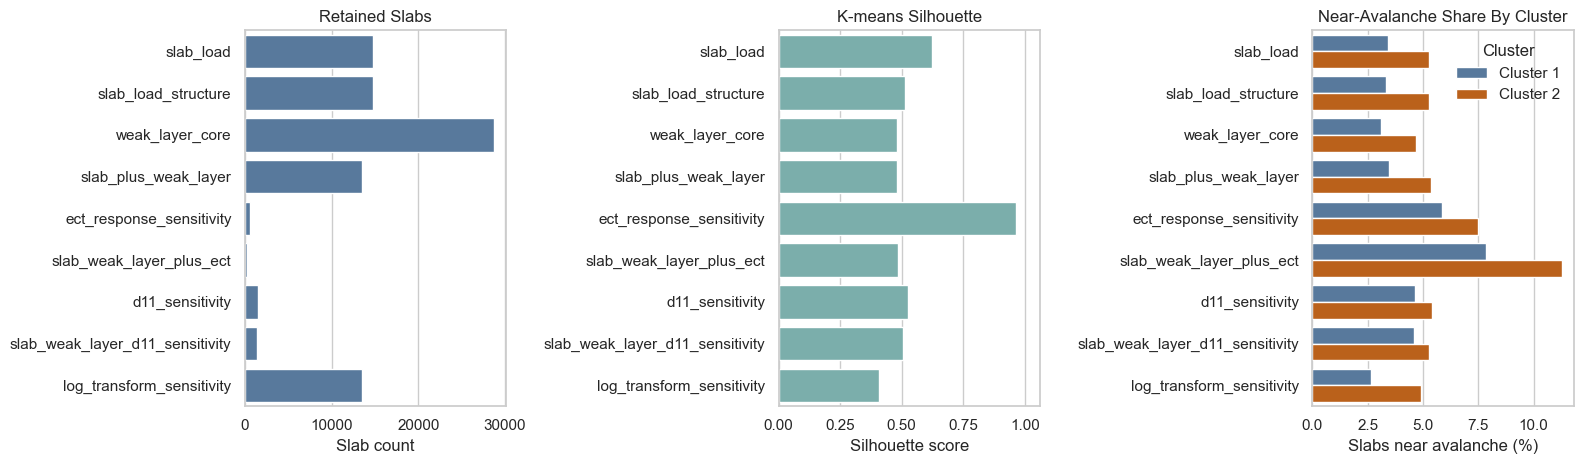

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.barplot(
    data=feature_set_summary_df,
    x="total_slabs_retained",
    y="feature_set",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Retained Slabs")
axes[0].set_xlabel("Slab count")
axes[0].set_ylabel("")

sns.barplot(
    data=feature_set_summary_df,
    x="kmeans_silhouette_score",
    y="feature_set",
    color="#72B7B2",
    ax=axes[1],
)
axes[1].set_title("K-means Silhouette")
axes[1].set_xlabel("Silhouette score")
axes[1].set_ylabel("")
axes[1].set_xlim(0, max(0.05, feature_set_summary_df["kmeans_silhouette_score"].max() * 1.1))

sns.barplot(
    data=cluster_comparison_df,
    x="percent_slabs_near_avalanche",
    y="feature_set",
    hue="cluster_label",
    palette={"Cluster 1": "#4C78A8", "Cluster 2": "#D55E00"},
    ax=axes[2],
)
axes[2].set_title("Near-Avalanche Share By Cluster")
axes[2].set_xlabel("Slabs near avalanche (%)")
axes[2].set_ylabel("")
axes[2].legend(title="Cluster", frameon=False)

fig.tight_layout()

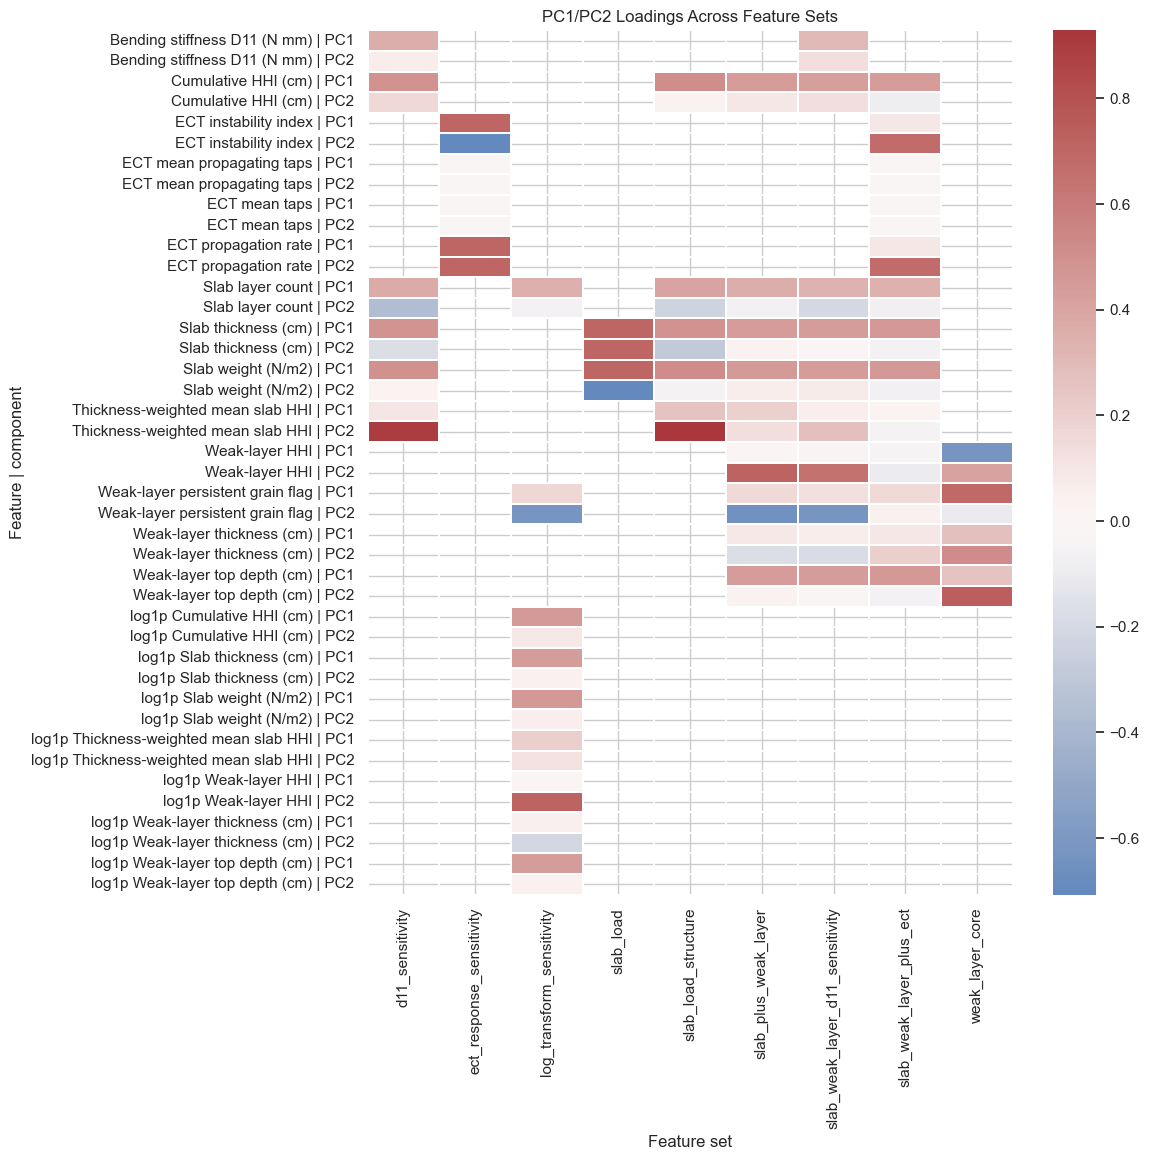

In [10]:
loading_heatmap_df = pca_loading_comparison_df.melt(
    id_vars=["feature_set", "display_name"],
    value_vars=["PC1", "PC2"],
    var_name="component",
    value_name="loading",
)
loading_heatmap_df["feature_component"] = (
    loading_heatmap_df["display_name"] + " | " + loading_heatmap_df["component"]
)
loading_pivot_df = loading_heatmap_df.pivot_table(
    index="feature_component",
    columns="feature_set",
    values="loading",
    aggfunc="first",
)

fig, axis = plt.subplots(figsize=(12, max(5, 0.28 * len(loading_pivot_df))))
sns.heatmap(
    loading_pivot_df,
    cmap="vlag",
    center=0,
    linewidths=0.2,
    linecolor="white",
    ax=axis,
)
axis.set_title("PC1/PC2 Loadings Across Feature Sets")
axis.set_xlabel("Feature set")
axis.set_ylabel("Feature | component")
fig.tight_layout()